# Compare temporal particle heterogeneity across cases

This notebook loads the `*_heterogeneity_timeseries.nc` files generated by `analyze_particles.ipynb` and creates three side-by-side panels. Each panel represents one particle class and each line represents one flow case.

Only the configuration cell normally needs editing:

- add or remove entries in `CASES`;
- assign each case a plot label directly in that list;
- choose the three particle classes through robust filename/metadata substrings;
- set the comparison name and title used for saved figures.

The notebook also stores the loaded comparison data in long-format CSV and NetCDF files so the same time series can be reused later without reopening every case directory.

In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys
import importlib
import re

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


# Notebook location:
# THESIS/z.parcels_postprocessing/notebooks/compare_particle_heterogeneity.ipynb
NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent

for path in [
    PROJECT_DIR,
    PROJECT_DIR / "z.flow_postprocessing",
    PROJECT_DIR / "z.parcels_postprocessing",
]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)


import scripts.notebook_helpers as phelp
import theme.plot_theme as ptheme

for module in [phelp, ptheme]:
    importlib.reload(module)

ptheme.apply_theme()

RESULTS_ROOT = (NB_DIR / "../results").resolve()

print(f"Notebook dir : {NB_DIR}")
print(f"Project dir  : {PROJECT_DIR}")
print(f"Results root : {RESULTS_ROOT}")

Notebook dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\notebooks
Project dir  : C:\Users\Jelle Gortemaker\Documents\Thesis
Results root : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results


In [2]:
# ============================================================
# 2. COMPARISON SETTINGS
# ============================================================

# Add or remove cases here. The number of cases is fully manual.
# "label" is used directly in the legend and saved comparison metadata.
# Optional entries: "color" and "linestyle".
CASES = [
    {"case_name": "run_dec1", "label": "DEC-1"},
]

PARTICLE_CLASSES = [
    {"match": "passive", "label": "Passive particles"},
    {"match": "taueff30s", "label": r"$\tau_p=30$ s"},
    {"match": "taueff60s", "label": r"$\tau_p=1$ min"},
]

COMPARISON_NAME = "selected_cases_temporal_heterogeneity"
COMPARISON_TITLE = "Temporal evolution of particle spatial heterogeneity"

# Plot interval. Use None to keep the complete available interval.
PLOT_START_DAY = None
PLOT_END_DAY = None

# Keep None or 1 for the stored three-hourly series without smoothing.
# An integer > 1 applies a centred rolling mean over that many observations.
ROLLING_WINDOW_OBS = None

SHOW_RANDOM_REFERENCE = True
SAVE_FIGURE = True
SAVE_COMPARISON_DATA = True
SHOW_SUMMARY_TABLE = True

COMPARISON_DIR = RESULTS_ROOT / "_comparisons" / COMPARISON_NAME
FIGURE_PATH = COMPARISON_DIR / f"{COMPARISON_NAME}.png"
TIMESERIES_CSV_PATH = COMPARISON_DIR / f"{COMPARISON_NAME}_timeseries.csv"
TIMESERIES_NC_PATH = COMPARISON_DIR / f"{COMPARISON_NAME}_timeseries.nc"
SUMMARY_CSV_PATH = COMPARISON_DIR / f"{COMPARISON_NAME}_summary.csv"

if SAVE_FIGURE or SAVE_COMPARISON_DATA:
    COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

if len(PARTICLE_CLASSES) != 3:
    raise ValueError("PARTICLE_CLASSES must contain exactly three entries.")

print(f"Comparison output: {COMPARISON_DIR}")

Comparison output: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\_comparisons\selected_cases_temporal_heterogeneity


In [3]:
# ============================================================
# 3. LOAD HETEROGENEITY FILES
# ============================================================


def _normalise_text(value):
    return "" if value is None else str(value).strip().lower()


def _heterogeneity_files(case_name):
    directory = RESULTS_ROOT / case_name / "metrics" / "voronoi"
    files = sorted(directory.glob("*_heterogeneity_timeseries.nc"))
    if not files:
        raise FileNotFoundError(
            f"No *_heterogeneity_timeseries.nc files found for {case_name!r} in:\n"
            f"{directory}\n"
            "Run the updated analyze_particles notebook for this case first."
        )
    return files


def _read_file_identity(path):
    with xr.open_dataset(path) as ds:
        return {
            "path": path,
            "particle_tag": str(ds.attrs.get("particle_tag", "")),
            "particle_label": str(ds.attrs.get("particle_label", "")),
            "case_name_attr": str(ds.attrs.get("case_name", "")),
        }


def _resolve_particle_file(case_name, match):
    match_norm = _normalise_text(match)
    identities = [_read_file_identity(path) for path in _heterogeneity_files(case_name)]

    # Prefer an exact stored particle-tag match.
    exact = [
        item for item in identities
        if _normalise_text(item["particle_tag"]) == match_norm
    ]
    if len(exact) == 1:
        return exact[0]

    # Otherwise allow a substring match in tag, label, or filename.
    matches = []
    for item in identities:
        searchable = " | ".join([
            _normalise_text(item["particle_tag"]),
            _normalise_text(item["particle_label"]),
            _normalise_text(item["path"].name),
        ])
        if match_norm in searchable:
            matches.append(item)

    if len(matches) == 1:
        return matches[0]

    available = pd.DataFrame(identities)[
        ["particle_tag", "particle_label", "path"]
    ]

    if len(matches) == 0:
        raise KeyError(
            f"No particle file in case {case_name!r} matches {match!r}.\n"
            f"Available classes:\n{available.to_string(index=False)}"
        )

    raise KeyError(
        f"Particle selector {match!r} is ambiguous for case {case_name!r}.\n"
        f"Matches:\n{pd.DataFrame(matches).to_string(index=False)}"
    )


def _load_heterogeneity_series(case, particle):
    identity = _resolve_particle_file(case["case_name"], particle["match"])
    path = identity["path"]

    with xr.open_dataset(path) as ds_open:
        ds = ds_open.load()

    required = ["elapsed_days", "spatial_heterogeneity_index"]
    missing = [name for name in required if name not in ds]
    if missing:
        raise KeyError(f"Missing variables {missing} in {path}")

    elapsed_days = np.asarray(ds["elapsed_days"].values, dtype=float)
    heterogeneity = np.asarray(
        ds["spatial_heterogeneity_index"].values,
        dtype=float,
    )

    if "sigma_area_norm" in ds:
        sigma_area_norm = np.asarray(ds["sigma_area_norm"].values, dtype=float)
    else:
        sigma_area_norm = np.full_like(heterogeneity, np.nan, dtype=float)

    if "n_valid_voronoi_cells" in ds:
        n_valid = np.asarray(ds["n_valid_voronoi_cells"].values, dtype=float)
    else:
        n_valid = np.full_like(heterogeneity, np.nan, dtype=float)

    if "obs" in ds.coords:
        obs_index = np.asarray(ds["obs"].values)
    else:
        obs_index = np.arange(elapsed_days.size, dtype=int)

    frame = pd.DataFrame({
        "case_name": case["case_name"],
        "case_label": case["label"],
        "particle_key": particle["match"],
        "particle_panel_label": particle["label"],
        "source_particle_tag": identity["particle_tag"],
        "source_particle_label": identity["particle_label"],
        "obs_index": obs_index,
        "elapsed_days": elapsed_days,
        "spatial_heterogeneity_index": heterogeneity,
        "sigma_area_norm": sigma_area_norm,
        "n_valid_voronoi_cells": n_valid,
        "source_file": str(path),
    })

    valid = (
        np.isfinite(frame["elapsed_days"])
        & np.isfinite(frame["spatial_heterogeneity_index"])
    )
    frame = frame.loc[valid].copy()

    if PLOT_START_DAY is not None:
        frame = frame.loc[frame["elapsed_days"] >= float(PLOT_START_DAY)].copy()
    if PLOT_END_DAY is not None:
        frame = frame.loc[frame["elapsed_days"] <= float(PLOT_END_DAY)].copy()

    frame = frame.sort_values("elapsed_days").reset_index(drop=True)

    if ROLLING_WINDOW_OBS is not None and int(ROLLING_WINDOW_OBS) > 1:
        frame["spatial_heterogeneity_plot"] = (
            frame["spatial_heterogeneity_index"]
            .rolling(
                window=int(ROLLING_WINDOW_OBS),
                center=True,
                min_periods=1,
            )
            .mean()
        )
    else:
        frame["spatial_heterogeneity_plot"] = frame[
            "spatial_heterogeneity_index"
        ]

    return frame


frames = []
file_index_rows = []

for case in CASES:
    for particle in PARTICLE_CLASSES:
        frame = _load_heterogeneity_series(case, particle)
        frames.append(frame)

        first = frame.iloc[0]
        file_index_rows.append({
            "case_name": case["case_name"],
            "case_label": case["label"],
            "particle_selector": particle["match"],
            "particle_panel_label": particle["label"],
            "source_particle_tag": first["source_particle_tag"],
            "source_particle_label": first["source_particle_label"],
            "n_observations": len(frame),
            "start_day": float(frame["elapsed_days"].min()),
            "end_day": float(frame["elapsed_days"].max()),
            "source_file": first["source_file"],
        })

heterogeneity_long = pd.concat(frames, ignore_index=True)
heterogeneity_file_index = pd.DataFrame(file_index_rows)

display(heterogeneity_file_index)

FileNotFoundError: No *_heterogeneity_timeseries.nc files found for 'run_dec1' in:
C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_dec1\metrics\voronoi
Run the updated analyze_particles notebook for this case first.

C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_26092\2716749791.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.84))


Saved figure: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\selected_cases_temporal_heterogeneity\selected_cases_temporal_heterogeneity.png


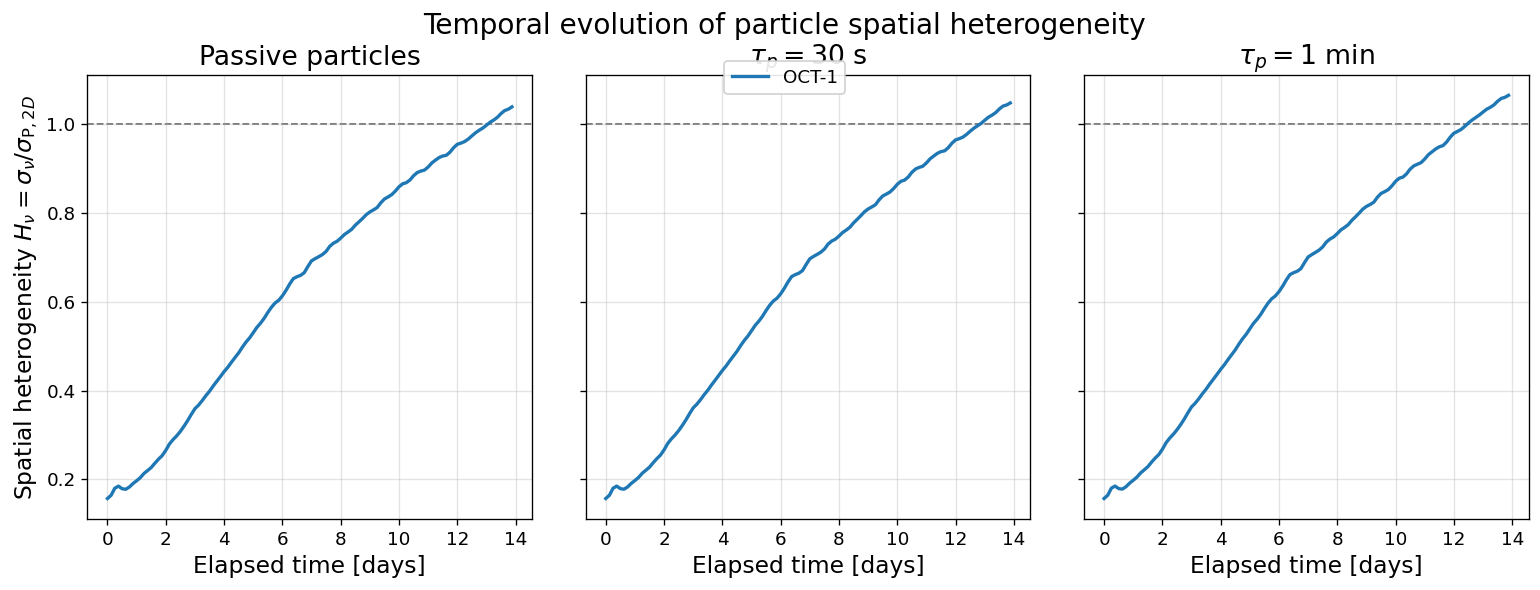

In [ ]:
# ============================================================
# 4. THREE-PANEL TEMPORAL HETEROGENEITY COMPARISON
# ============================================================

# One case style is reused in all three particle panels.
categorical_cmap = plt.get_cmap("tab10")
case_styles = {}

for i, case in enumerate(CASES):
    case_styles[case["case_name"]] = {
        "color": case.get("color", categorical_cmap(i % 10)),
        "linestyle": case.get("linestyle", "-"),
        "label": case["label"],
    }

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15.5, 4.8),
    sharex=True,
    sharey=True,
    facecolor="white",
    gridspec_kw={"wspace": 0.12},
)

fig.suptitle(COMPARISON_TITLE, y=0.99)

for ax, particle in zip(axes, PARTICLE_CLASSES):
    ax.set_facecolor("white")

    if SHOW_RANDOM_REFERENCE:
        ax.axhline(
            1.0,
            color="0.35",
            linestyle="--",
            linewidth=1.1,
            alpha=0.85,
            zorder=1,
        )

    for case in CASES:
        subset = heterogeneity_long.loc[
            (heterogeneity_long["case_name"] == case["case_name"])
            & (heterogeneity_long["particle_key"] == particle["match"])
        ].sort_values("elapsed_days")

        style = case_styles[case["case_name"]]
        ax.plot(
            subset["elapsed_days"],
            subset["spatial_heterogeneity_plot"],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=2.0,
            label=style["label"],
        )

    ax.set_title(particle["label"])
    ax.set_xlabel("Elapsed time [days]")
    ax.grid(True, alpha=getattr(ptheme, "GRID_ALPHA", 0.30))

axes[0].set_ylabel(
    r"Spatial heterogeneity $H_\nu=\sigma_\nu/\sigma_{\mathrm{P},2D}$"
)

# One shared legend keeps case identity consistent across panels.
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.92),
    ncol=max(1, min(len(CASES), 5)),
    frameon=True,
    fontsize=getattr(ptheme, "LEGEND_FONTSIZE", 11),
)

fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.84))

if SAVE_FIGURE:
    fig.savefig(
        FIGURE_PATH,
        dpi=getattr(ptheme, "SAVE_DPI", 250),
        facecolor="white",
        bbox_inches="tight",
    )
    print(f"Saved figure: {FIGURE_PATH}")

plt.show()

In [ ]:
# ============================================================
# 5. SUMMARY TABLE + COMPARISON-READY STORAGE
# ============================================================

summary_table = (
    heterogeneity_long
    .groupby(
        [
            "case_name",
            "case_label",
            "particle_key",
            "particle_panel_label",
            "source_particle_tag",
            "source_particle_label",
        ],
        as_index=False,
    )
    .agg(
        n_observations=("spatial_heterogeneity_index", "count"),
        start_day=("elapsed_days", "min"),
        end_day=("elapsed_days", "max"),
        heterogeneity_mean=("spatial_heterogeneity_index", "mean"),
        heterogeneity_median=("spatial_heterogeneity_index", "median"),
        heterogeneity_std_time=("spatial_heterogeneity_index", "std"),
        heterogeneity_min=("spatial_heterogeneity_index", "min"),
        heterogeneity_max=("spatial_heterogeneity_index", "max"),
    )
)

if SHOW_SUMMARY_TABLE:
    display(summary_table)

if SAVE_COMPARISON_DATA:
    heterogeneity_long.to_csv(TIMESERIES_CSV_PATH, index=False)
    summary_table.to_csv(SUMMARY_CSV_PATH, index=False)

    # Long-format NetCDF: one sample corresponds to one case–particle–time row.
    storage_df = heterogeneity_long.reset_index(drop=True)
    comparison_ds = xr.Dataset(
        data_vars={
            "elapsed_days": ("sample", storage_df["elapsed_days"].to_numpy(float)),
            "spatial_heterogeneity_index": (
                "sample",
                storage_df["spatial_heterogeneity_index"].to_numpy(float),
            ),
            "sigma_area_norm": (
                "sample",
                storage_df["sigma_area_norm"].to_numpy(float),
            ),
            "n_valid_voronoi_cells": (
                "sample",
                storage_df["n_valid_voronoi_cells"].to_numpy(float),
            ),
            "obs_index": ("sample", storage_df["obs_index"].to_numpy()),
            "case_name": ("sample", storage_df["case_name"].astype(str).to_numpy()),
            "case_label": ("sample", storage_df["case_label"].astype(str).to_numpy()),
            "particle_key": (
                "sample",
                storage_df["particle_key"].astype(str).to_numpy(),
            ),
            "particle_panel_label": (
                "sample",
                storage_df["particle_panel_label"].astype(str).to_numpy(),
            ),
            "source_particle_tag": (
                "sample",
                storage_df["source_particle_tag"].astype(str).to_numpy(),
            ),
            "source_particle_label": (
                "sample",
                storage_df["source_particle_label"].astype(str).to_numpy(),
            ),
            "source_file": (
                "sample",
                storage_df["source_file"].astype(str).to_numpy(),
            ),
        },
        coords={"sample": np.arange(len(storage_df), dtype=int)},
        attrs={
            "comparison_name": COMPARISON_NAME,
            "comparison_title": COMPARISON_TITLE,
            "n_cases": int(len(CASES)),
            "n_particle_panels": int(len(PARTICLE_CLASSES)),
            "rolling_window_obs": (
                1 if ROLLING_WINDOW_OBS is None else int(ROLLING_WINDOW_OBS)
            ),
            "random_reference_value": 1.0,
        },
    )
    comparison_ds.to_netcdf(TIMESERIES_NC_PATH)

    print(f"Saved time-series CSV : {TIMESERIES_CSV_PATH}")
    print(f"Saved time-series NC  : {TIMESERIES_NC_PATH}")
    print(f"Saved summary CSV     : {SUMMARY_CSV_PATH}")

,case_name,case_label,particle_key,particle_panel_label,source_particle_tag,source_particle_label,n_observations,start_day,end_day,heterogeneity_mean,heterogeneity_median,heterogeneity_std_time,heterogeneity_min,heterogeneity_max
0,run_oct1,OCT-1,passive,Passive particles,passive,Passive particles,112,0.0,13.875,0.635767,0.685853,0.274374,0.156634,1.039196
1,run_oct1,OCT-1,taueff30s,$\tau_p=30$ s,smmrg_taueff30s_Steff1p66896em05,"τₚ=30 s, St=1.67e-05",112,0.0,13.875,0.640853,0.690488,0.277543,0.156634,1.048033
2,run_oct1,OCT-1,taueff60s,$\tau_p=1$ min,smmrg_taueff60s_Steff3p33791em05,"τₚ=1 min, St=3.34e-05",112,0.0,13.875,0.647034,0.694530,0.282181,0.156635,1.065235


Saved time-series CSV : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\selected_cases_temporal_heterogeneity\selected_cases_temporal_heterogeneity_timeseries.csv
Saved time-series NC  : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\selected_cases_temporal_heterogeneity\selected_cases_temporal_heterogeneity_timeseries.nc
Saved summary CSV     : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\selected_cases_temporal_heterogeneity\selected_cases_temporal_heterogeneity_summary.csv


## Optional coupling to flow diagnostics

A useful next step is to time-align the heterogeneity series with flow diagnostics from the same case and layer. Suitable diagnostics include:

- the domain or local area fraction with \(|Ro|>0.5\), often denoted \(P_{Ro}\);
- area-mean strain or the upper percentile of strain;
- the fraction of convergent surface flow;
- EKE or enstrophy;
- dissipation rate or a submesoscale energy fraction.

The strongest analysis is usually not just an instantaneous correlation. Particle clustering may react with a delay. For a diagnostic \(D\), compare

\[
H_\nu(t) \quad \text{with} \quad D(t-\tau)
\]

for a range of lags \(\tau\). Positive \(\tau\) then means that the flow diagnostic leads the heterogeneity response. Perform this within each case first; pooling raw values across cases can produce a correlation that merely reflects different case means.

The disabled template below supports one NetCDF or CSV diagnostics file per case and creates a three-panel scatter comparison. It can also impose a chosen lag before time matching.

In [ ]:
# ============================================================
# 6. OPTIONAL FLOW-DIAGNOSTIC COUPLING
# ============================================================

RUN_FLOW_HETEROGENEITY_COUPLING = False

# Expected file content:
#   - one time variable, e.g. "elapsed_days";
#   - one flow-diagnostic variable, e.g. "PRo".
# Paths can point to either NetCDF or CSV files.
FLOW_DIAGNOSTIC_SETTINGS = {
    "diagnostic_variable": "PRo",
    "diagnostic_label": r"$P_{Ro}(|Ro|>0.5)$",
    "time_variable": "elapsed_days",
    "lag_days": 0.0,
    "matching_tolerance_days": 0.07,
    "case_files": {
        # "run_mar1": RESULTS_ROOT / "run_mar1" / "metrics" / "flow_diagnostics.nc",
        # "run_nov1": RESULTS_ROOT / "run_nov1" / "metrics" / "flow_diagnostics.nc",
    },
}


def _load_flow_diagnostic(path, time_variable, diagnostic_variable):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    if path.suffix.lower() == ".csv":
        frame = pd.read_csv(path)
    else:
        with xr.open_dataset(path) as ds_open:
            ds = ds_open[[time_variable, diagnostic_variable]].load()
        frame = ds.to_dataframe().reset_index()

    frame = frame[[time_variable, diagnostic_variable]].copy()
    frame = frame.rename(columns={
        time_variable: "flow_elapsed_days",
        diagnostic_variable: "flow_diagnostic",
    })
    frame = frame.dropna().sort_values("flow_elapsed_days")
    return frame


if RUN_FLOW_HETEROGENEITY_COUPLING:
    diagnostic_name = FLOW_DIAGNOSTIC_SETTINGS["diagnostic_variable"]
    diagnostic_label = FLOW_DIAGNOSTIC_SETTINGS["diagnostic_label"]
    lag_days = float(FLOW_DIAGNOSTIC_SETTINGS["lag_days"])
    tolerance = float(FLOW_DIAGNOSTIC_SETTINGS["matching_tolerance_days"])

    coupled_frames = []

    for case in CASES:
        case_name = case["case_name"]
        if case_name not in FLOW_DIAGNOSTIC_SETTINGS["case_files"]:
            raise KeyError(
                f"No flow-diagnostic file configured for {case_name!r}."
            )

        flow_frame = _load_flow_diagnostic(
            FLOW_DIAGNOSTIC_SETTINGS["case_files"][case_name],
            FLOW_DIAGNOSTIC_SETTINGS["time_variable"],
            diagnostic_name,
        )

        # Positive lag compares H(t) with D(t-lag): move the diagnostic
        # timestamps forward before matching them to the heterogeneity time.
        flow_frame["match_day"] = flow_frame["flow_elapsed_days"] + lag_days

        for particle in PARTICLE_CLASSES:
            h_frame = heterogeneity_long.loc[
                (heterogeneity_long["case_name"] == case_name)
                & (heterogeneity_long["particle_key"] == particle["match"]),
                ["elapsed_days", "spatial_heterogeneity_index"],
            ].sort_values("elapsed_days")

            merged = pd.merge_asof(
                h_frame,
                flow_frame.sort_values("match_day"),
                left_on="elapsed_days",
                right_on="match_day",
                direction="nearest",
                tolerance=tolerance,
            ).dropna(subset=["flow_diagnostic"])

            merged["case_name"] = case_name
            merged["case_label"] = case["label"]
            merged["particle_key"] = particle["match"]
            merged["particle_panel_label"] = particle["label"]
            coupled_frames.append(merged)

    flow_heterogeneity = pd.concat(coupled_frames, ignore_index=True)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15.5, 4.8),
        sharey=True,
        facecolor="white",
        gridspec_kw={"wspace": 0.12},
    )

    correlation_rows = []

    for ax, particle in zip(axes, PARTICLE_CLASSES):
        for case in CASES:
            subset = flow_heterogeneity.loc[
                (flow_heterogeneity["case_name"] == case["case_name"])
                & (flow_heterogeneity["particle_key"] == particle["match"])
            ]
            style = case_styles[case["case_name"]]

            ax.scatter(
                subset["flow_diagnostic"],
                subset["spatial_heterogeneity_index"],
                s=18,
                alpha=0.55,
                color=style["color"],
                label=style["label"],
            )

            r = subset[
                ["flow_diagnostic", "spatial_heterogeneity_index"]
            ].corr().iloc[0, 1]
            correlation_rows.append({
                "case_name": case["case_name"],
                "case_label": case["label"],
                "particle_key": particle["match"],
                "particle_panel_label": particle["label"],
                "diagnostic": diagnostic_name,
                "lag_days": lag_days,
                "pearson_r_descriptive": r,
                "n_pairs": len(subset),
            })

        ax.set_title(particle["label"])
        ax.set_xlabel(diagnostic_label)
        ax.grid(True, alpha=getattr(ptheme, "GRID_ALPHA", 0.30))

    axes[0].set_ylabel(
        r"Spatial heterogeneity $H_\nu=\sigma_\nu/\sigma_{\mathrm{P},2D}$"
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.92),
        ncol=max(1, min(len(CASES), 5)),
    )
    fig.suptitle(
        f"Flow diagnostic versus particle heterogeneity; lag={lag_days:g} days",
        y=0.99,
    )
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.84))
    plt.show()

    flow_heterogeneity_correlations = pd.DataFrame(correlation_rows)
    display(flow_heterogeneity_correlations)
